# Project in Econometrics 2:
## **Research question:** Does increase in GDP per capita improve life expectancy?
## Estimating causal effect of GDP per capita on life expectancy
**Students:**
- Durmishkhan Gigineishvili 
- Giorgi Shekiladze
- Elene Dzneladze
- Nanuka Kasradze
- Nika Kobakhidze

# Loading necessary libraries

In [2]:
library(dplyr)       # Data manipulation
library(tidyr)       # Reshaping data (e.g., pivot_longer)
library(ggplot2)     # Data visualization
library(fixest)      # Fixed effects models, IV regressions
library(plm)         # Panel data models
library(lmtest)      # Panel tests like pbgtest (Wooldridge test)
library(car)         # Used for testing for multicollinearity


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'plm'


The following objects are masked from 'package:dplyr':

    between, lag, lead


Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Loading required package: carData


Attaching package: 'car'


The following object is masked from 'package:dplyr':

    recode




# **Dataset info:**
### Our dataset was downloaded from WDI (world bank developement indicators) dataset with variables of our choice and time span of 50 years from 1975 to 2024. Dataset overall includes 217 countries around the world.
## In our project we are going to estimate what's causal effect of GDP per capita on life expectancy

### Loading the dataset:

In [3]:
df <- read.csv("group_16_data.csv")

### Getting rid of empty observations, potential duplicates

In [4]:
data <- read.csv("group_16_data.csv", na.strings = "..")

# Remove duplicate rows based on Country_Name and Time
data <- data[!duplicated(data[c("Country_Name", "Time")]), ]

# Investigating dataset characteristics

### Showing how the dataset looks like:
Note that countries were arranged in excel from A to Z and then saved as CSV file that's why you see only Afghanistan in first 6 rows, actually this will be the case for first 50 observations, then another country with its observations across 50 years comes etc. It's a panel data as you have noticed from description in the beginning.

In [5]:
head(data)

,Time,Country_Name,Life_expectancy,GDP_per_capita,Age_dependency_ratio_young,Urban_population,Fertility_rate,Immunization_DPT,Immunization_measles,Exports,FDI
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>
1,1975,Afghanistan,39.994,NA,86.01346,13.641,7.542,NA,NA,300000007,NA
2,1976,Afghanistan,40.518,NA,86.72496,14.074,7.561,NA,NA,337777778,NA
3,1977,Afghanistan,41.082,NA,87.42769,14.517,7.591,NA,NA,344444451,NA
4,1978,Afghanistan,40.086,NA,88.12432,14.973,7.599,NA,NA,357777771,NA
5,1979,Afghanistan,38.844,NA,88.82592,15.442,7.612,NA,NA,NA,NA
6,1980,Afghanistan,39.258,NA,89.55754,15.995,7.643,4,11,NA,NA


### Extracting column names:

In [6]:
colnames(df)

[1] "Time"                       "Country_Name"              
 [3] "Life_expectancy"            "GDP_per_capita"            
 [5] "Age_dependency_ratio_young" "Urban_population"          
 [7] "Fertility_rate"             "Immunization_DPT"          
 [9] "Immunization_measles"       "Exports"                   
[11] "FDI"

# Description of variables used:
    1) Life expectancy - calculated in years
    2) GDP_per_capita - calculated in current USD
    3) Age_dependency_ratio_young - shows how many percent of working population consists of young people (We ended up dropping it due to multicollinearity issue)
    4) Urban_population - percentage of people living in urban areas 
    5) Fertility_rate - birth per woman
    6) Immunization_DPT - percentage of small babies immunized against DPT
    7) Immunization_measles - percentage of small babies immunized against measles
    8) Exports - Net exports measured in current USD (Used as an IV for GDP per capita)
    9) FDI - Foreign direct investment measured in terms of % of GDP (Used as an IV for GDP per capita)

### So for the main goal of our Project we used **Life expectancy as dependent variable**, **GDP per capita as our variable of interest (whose effect we were trying to estimate on life expectancy)**, other 5 variables as control variables, the other 2 variables were used as IV's for GDP per capita.

### Data dimensions:

In [7]:
dim(data)

[1] 10850    11

### So, we initially have more than 10 000 observations in the raw dataset. However, due to missing values, observations in FE regression drops to 7,565 and in the combination of FE and IV to 6190. Though, their amount is still more than 5000 as our lecturer recommended and is enough for getting reliable and tangible results.

### Plot of GDP per capita showing fluctuations over time with example of one small economy such as Georgia:

`geom_smooth()` using formula = 'y ~ x'


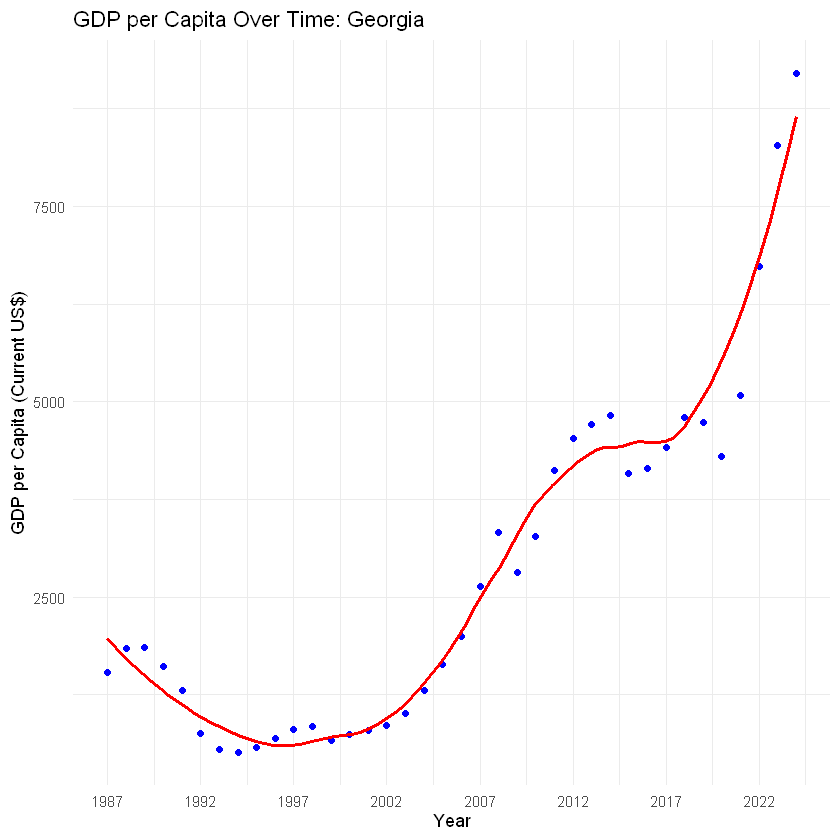

In [8]:
geo_data <- data %>%
  filter(Country_Name == "Georgia", !is.na(Time), !is.na(GDP_per_capita)) %>%
  arrange(Time) %>%
  mutate(Time_Index = row_number() - 1)

# Define breaks on Time_Index and corresponding year labels
breaks <- seq(0, max(geo_data$Time_Index), by = 5)  # every 5 years index
labels <- geo_data$Time[breaks + 1]  # +1 because Time_Index starts at 0 but row_number() starts at 1

ggplot(geo_data, aes(x = Time_Index, y = GDP_per_capita)) +
  geom_point(color = "blue") +
  geom_smooth(se = FALSE, method = "loess", span = 0.5, color = "red") +
  scale_x_continuous(
    breaks = breaks,
    labels = labels
  ) +
  labs(
    title = "GDP per Capita Over Time: Georgia",
    x = "Year",
    y = "GDP per Capita (Current US$)"
  ) +
  theme_minimal()

### Plot of GDP per capita showing fluctuations over time with example of one large economy such as France:

`geom_smooth()` using formula = 'y ~ x'


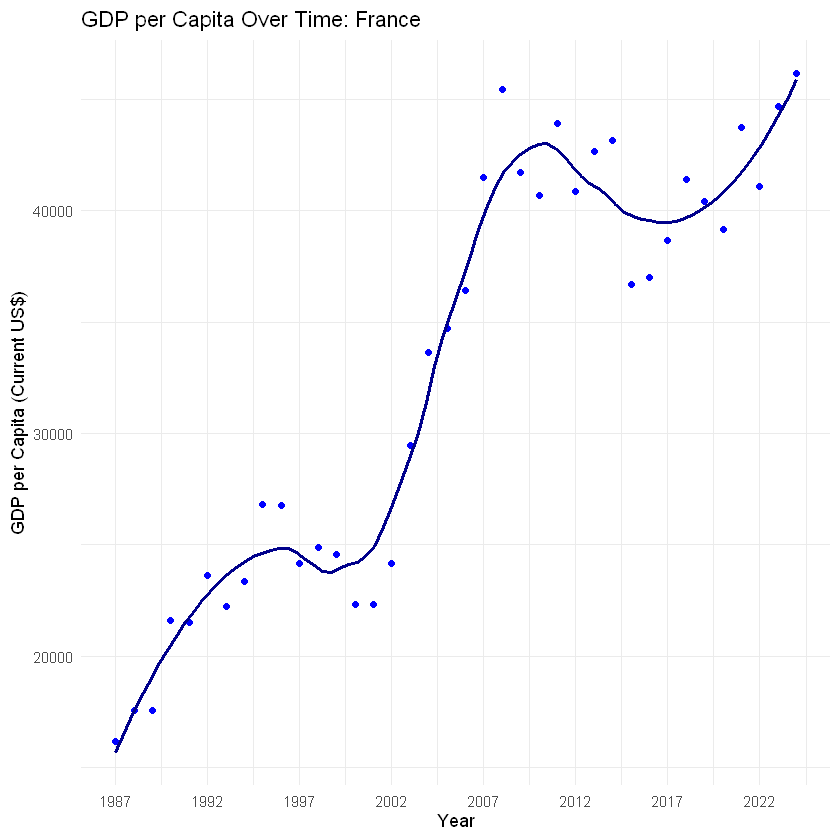

In [9]:
geo_data <- data %>%
  filter(Country_Name == "France", Time >= 1987, !is.na(GDP_per_capita)) %>%
  arrange(Time) %>%
  mutate(Time_Index = row_number() - 1)

# Define breaks on Time_Index and corresponding year labels
breaks <- seq(0, max(geo_data$Time_Index), by = 5)  # every 5 years index
labels <- geo_data$Time[breaks + 1]  # +1 because Time_Index starts at 0

ggplot(geo_data, aes(x = Time_Index, y = GDP_per_capita)) +
  geom_point(color = "blue") +
  geom_smooth(se = FALSE, method = "loess", span = 0.5, color = "darkblue") +
  scale_x_continuous(
    breaks = breaks,
    labels = labels
  ) +
  labs(
    title = "GDP per Capita Over Time: France",
    x = "Year",
    y = "GDP per Capita (Current US$)"
  ) +
  theme_minimal()

### **Note that** on the graph we filtered GDP per capita for France to start from 1987 instead of 1975 because for Georgia it was available from 1987, so for the sake of consistency we though that was necessary for quality demonstration purposes.

### As you see in both of the cases common major decrease in GDP came in 2008-2009 which is related to Global Banking Crisis, another common significant drop (**pay attention to specific point(s) not the trend line**) came in 2020-2021 which corresponds to breakout of COVID-19. That pattern once again shows why we should include Time fixed effects as well as country fixed effects in the following parts. Note that time fixed effect will eliminate potential bias coming from unobserved variation due to G.F.C, COVID and other events; As for as geographical and cultural effects and other time invariant effects, they will be eliminated using country fixed effects, its crucial because our dataset contains data about all countries around the world.

### We can also observe fluctuations in life expectancy for Georgia:

`geom_smooth()` using formula = 'y ~ x'


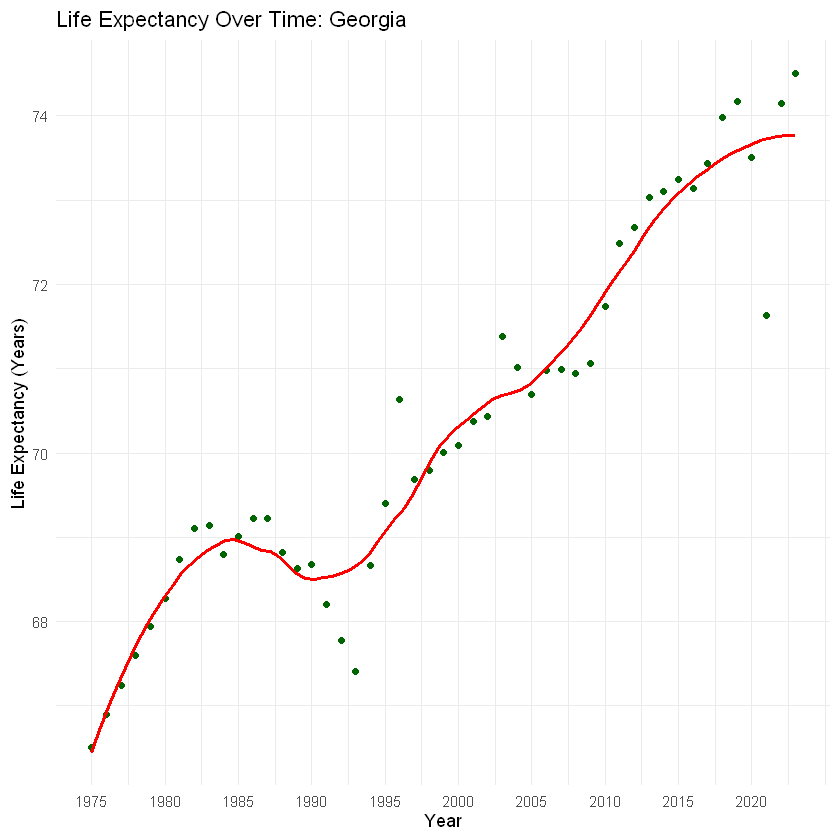

In [10]:
geo_data <- data %>%
  filter(Country_Name == "Georgia", !is.na(Time), !is.na(Life_expectancy)) %>%
  arrange(Time) %>%
  mutate(Time_Index = row_number() - 1)

# Define breaks and labels
breaks <- seq(0, max(geo_data$Time_Index), by = 5)
labels <- geo_data$Time[breaks + 1]  # Adjusting for Time_Index starting at 0

# Plot Life Expectancy over time
ggplot(geo_data, aes(x = Time_Index, y = Life_expectancy)) +
  geom_point(color = "darkgreen") +
  geom_smooth(se = FALSE, method = "loess", span = 0.5, color = "red") +
  scale_x_continuous(
    breaks = breaks,
    labels = labels
  ) +
  labs(
    title = "Life Expectancy Over Time: Georgia",
    x = "Year",
    y = "Life Expectancy (Years)"
  ) +
  theme_minimal()

### Plotting life expectancy over time for France:

`geom_smooth()` using formula = 'y ~ x'


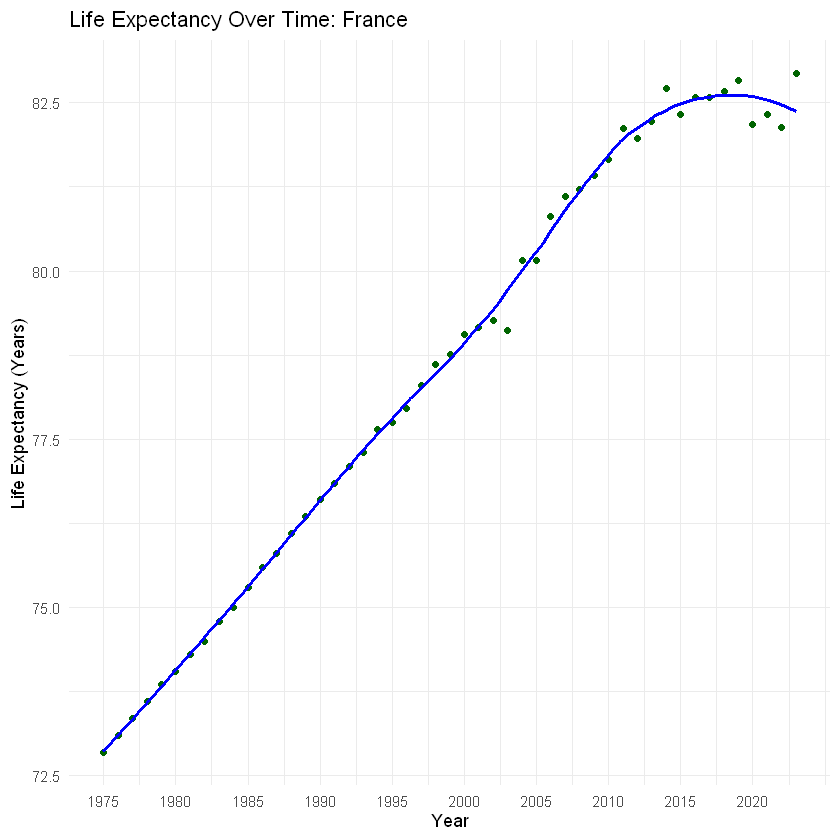

In [11]:
geo_data <- data %>%
  filter(Country_Name == "France", !is.na(Time), !is.na(Life_expectancy)) %>%
  arrange(Time) %>%
  mutate(Time_Index = row_number() - 1)

# Define breaks and labels
breaks <- seq(0, max(geo_data$Time_Index), by = 5)
labels <- geo_data$Time[breaks + 1]  # Adjusting for Time_Index starting at 0

# Plot Life Expectancy over time
ggplot(geo_data, aes(x = Time_Index, y = Life_expectancy)) +
  geom_point(color = "darkgreen") +
  geom_smooth(se = FALSE, method = "loess", span = 0.5, color = "blue") +
  scale_x_continuous(
    breaks = breaks,
    labels = labels
  ) +
  labs(
    title = "Life Expectancy Over Time: France",
    x = "Year",
    y = "Life Expectancy (Years)"
  ) +
  theme_minimal()

### You can observe same common effect here too especially due to COVID in both countries life expectancy decreased in 2020-2021. However, it's worth mentioning that in Georgia decrease was more dramatic probably primarily because of Healthcare services which apparently are at lower level compared to what's available in France on average.

## **Note:** to clarify and avoid confusion in the following graphs we are going to graph both of the variables for each country together where instead of trendline there will be a line constructed by connecting dots, so it's not going to be as smooth as on previous graphs as it has another purpose.

### Now let's observe GDP per capita and life expectancy together in in Georgia:
**Note** that GDP per capita and life expectancy were normalized in order to be able to put them together on one graph as their scales differ significantly

Warning message:
"NAs introduced by coercion"


Warning message:
"NAs introduced by coercion"
Warning message:
"Removed 13 rows containing missing values or values outside the scale range
(`geom_line()`)."


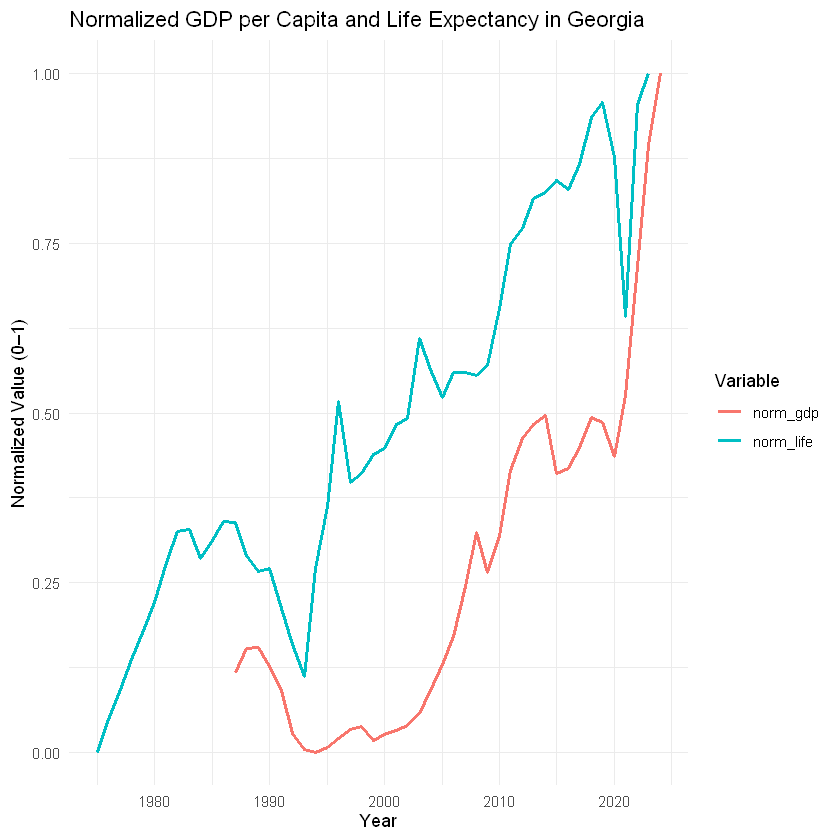

In [12]:
# Clean and convert
df <- df[df$Time != "", ]
df$Time <- as.numeric(df$Time)
df$GDP_per_capita <- as.numeric(df$GDP_per_capita)
df$Life_expectancy <- as.numeric(df$Life_expectancy)

# Filter for Georgia
georgia_df <- df %>% filter(Country_Name == "Georgia")

# Normalize both variables (min-max scaling)
georgia_df <- georgia_df %>%
  mutate(
    norm_gdp = (GDP_per_capita - min(GDP_per_capita, na.rm = TRUE)) /
               (max(GDP_per_capita, na.rm = TRUE) - min(GDP_per_capita, na.rm = TRUE)),
    
    norm_life = (Life_expectancy - min(Life_expectancy, na.rm = TRUE)) /
                (max(Life_expectancy, na.rm = TRUE) - min(Life_expectancy, na.rm = TRUE))
  )

# Reshape to long format
georgia_long <- georgia_df %>%
  select(Time, norm_gdp, norm_life) %>%
  pivot_longer(cols = c(norm_gdp, norm_life),
               names_to = "Variable", values_to = "Value")

# Plot
ggplot(georgia_long, aes(x = Time, y = Value, color = Variable)) +
  geom_line(linewidth = 1) +
  labs(title = "Normalized GDP per Capita and Life Expectancy in Georgia",
       x = "Year", y = "Normalized Value (0–1)", color = "Variable") +
  theme_minimal()

### As we see from the graphs above both GDP per capita and life expectacy have upwards trend showing that they are indeed positively correlated and as GDP per capita is causally linked with life expectancy we should expect B1 to be positive.

### We also can observe France's GDP per capita and life expectancy and see the same pattern:
**Note** that GDP per capita and life expectancy were normalized in order to be able to put them together on one graph as their scales differ significantly

Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_line()`)."


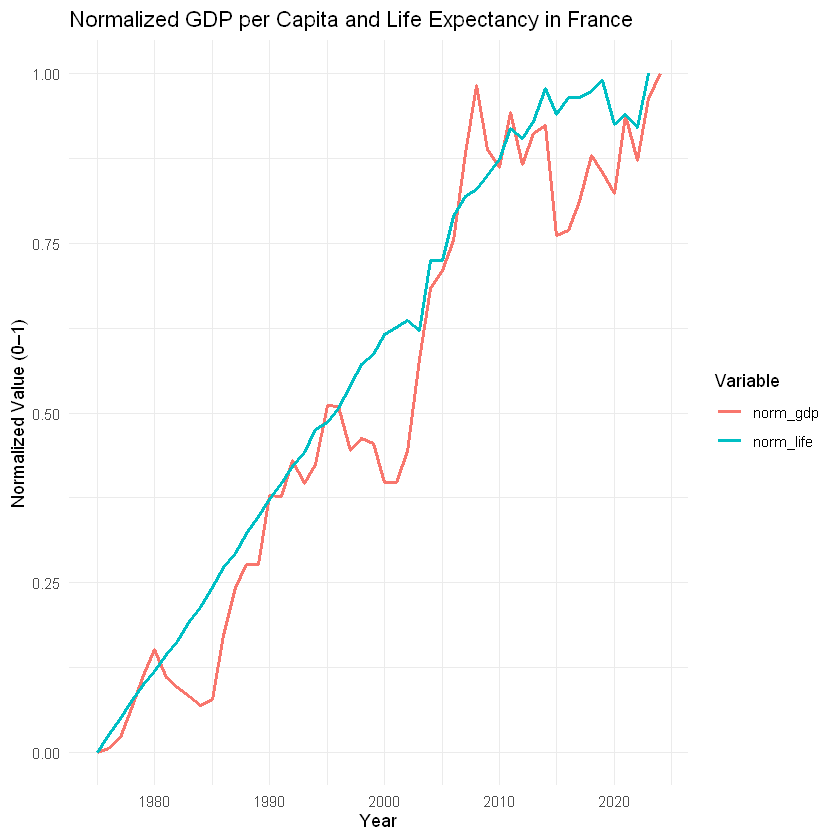

In [13]:
# Clean and convert
df <- df[df$Time != "", ]
df$Time <- as.numeric(df$Time)
df$GDP_per_capita <- as.numeric(df$GDP_per_capita)
df$Life_expectancy <- as.numeric(df$Life_expectancy)

# Filter for Georgia
georgia_df <- df %>% filter(Country_Name == "France")

# Normalize both variables (min-max scaling)
georgia_df <- georgia_df %>%
  mutate(
    norm_gdp = (GDP_per_capita - min(GDP_per_capita, na.rm = TRUE)) /
               (max(GDP_per_capita, na.rm = TRUE) - min(GDP_per_capita, na.rm = TRUE)),
    
    norm_life = (Life_expectancy - min(Life_expectancy, na.rm = TRUE)) /
                (max(Life_expectancy, na.rm = TRUE) - min(Life_expectancy, na.rm = TRUE))
  )

# Reshape to long format
georgia_long <- georgia_df %>%
  select(Time, norm_gdp, norm_life) %>%
  pivot_longer(cols = c(norm_gdp, norm_life),
               names_to = "Variable", values_to = "Value")

# Plot
ggplot(georgia_long, aes(x = Time, y = Value, color = Variable)) +
  geom_line(linewidth = 1) +
  labs(title = "Normalized GDP per Capita and Life Expectancy in France",
       x = "Year", y = "Normalized Value (0–1)", color = "Variable") +
  theme_minimal()

### As we see there is the same pattern of positive correlation between GDP per capita and life expectancy.

# Checking for multicollinearity:

In [14]:
model <- lm(Life_expectancy ~ GDP_per_capita + Age_dependency_ratio_young +
              Urban_population + Fertility_rate + Immunization_DPT +
              Immunization_measles + Exports + FDI, data = data)

# Compute VIF
vif(model)

GDP_per_capita Age_dependency_ratio_young 
                  1.971781                  14.215217 
          Urban_population             Fertility_rate 
                  1.994552                  13.911156 
          Immunization_DPT       Immunization_measles 
                  5.842281                   5.301955 
                   Exports                        FDI 
                  1.293459                   1.015846

# As we see VIF's of age dependency ratio and urban population is more than 10 , which signals multicollinearity issue, so we are going to drop one of the variables to remove multicollinearity problem, for that reason we are going to drop age dependency ratio:

In [15]:
model <- lm(Life_expectancy ~ GDP_per_capita +
              Urban_population + Fertility_rate + Immunization_DPT +
              Immunization_measles + Exports + FDI, data = data)

# Compute VIF
vif(model)

GDP_per_capita     Urban_population       Fertility_rate 
            1.735834             1.946400             2.544479 
    Immunization_DPT Immunization_measles              Exports 
            5.785821             5.301609             1.286796 
                 FDI 
            1.013947

# **Now as we see VIF's are well below threshold of 10 , at most they are around ~5 which is totally fine and we can carry on building our models**

### The OLS regression results above though shows that there is positive relationship between high GDP per capita and Life expectancy. However, it does not account for potential bias comming from time fixed, entity fixed or other ommited variables, and its standard error is also likely to be incorrect as it does not account for heteroskedasticity.

# **Baseline model OLS:**

In [16]:
OLS_model <- lm(
  Life_expectancy ~ log(GDP_per_capita) +
    Immunization_DPT +
    Immunization_measles +
    Urban_population +
    Fertility_rate,
  data = data
)
summary(OLS_model)


Call:
lm(formula = Life_expectancy ~ log(GDP_per_capita) + Immunization_DPT + 
    Immunization_measles + Urban_population + Fertility_rate, 
    data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-39.655  -1.935   0.411   2.419  13.663 

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)          50.421709   0.544978  92.521  < 2e-16 ***
log(GDP_per_capita)   2.325058   0.053841  43.184  < 2e-16 ***
Immunization_DPT      0.073848   0.005452  13.544  < 2e-16 ***
Immunization_measles -0.014817   0.005152  -2.876  0.00404 ** 
Urban_population      0.031434   0.003050  10.305  < 2e-16 ***
Fertility_rate       -2.329448   0.045168 -51.573  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4.088 on 7559 degrees of freedom
  (3285 observations deleted due to missingness)
Multiple R-squared:  0.8174,	Adjusted R-squared:  0.8173 
F-statistic:  6767 on 5 and 7559 DF,  p-value: < 2.2e-16


# **FE regression models:**

# Running fixed effects regression to deal with time fixed and country fixed effects:

In [17]:
fe_model <- feols(
  Life_expectancy ~ log(GDP_per_capita) + Immunization_DPT +
    Immunization_measles + Urban_population + Fertility_rate | Country_Name + Time,
  data = data
) # By default standard errors get clustered across countries

NOTE: 3,285 observations removed because of NA values (LHS: 232, RHS: 3,285).



### Why we are using log transformed GDP per capita? Because its values are large in size, probably skewed and harder to interpret but by applying log transformation, which is a monotonic transformation we:
    1) Reduce Skewness and Scale
    2) Can interpret results in terms of %
    3) Stabilize Variance


In [18]:
summary(fe_model) #Get the results of the FE regression

OLS estimation, Dep. Var.: Life_expectancy
Observations: 7,565
Fixed-effects: Country_Name: 192,  Time: 44
Standard-errors: Clustered (Country_Name) 
                      Estimate Std. Error  t value   Pr(>|t|)    
log(GDP_per_capita)   0.708864   0.292979  2.41950 1.6479e-02 *  
Immunization_DPT      0.062643   0.010671  5.87046 1.8930e-08 ***
Immunization_measles  0.013036   0.009348  1.39457 1.6476e-01    
Urban_population      0.040404   0.032364  1.24841 2.1341e-01    
Fertility_rate       -0.922537   0.268895 -3.43085 7.3739e-04 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2.24037     Adj. R2: 0.943322
                Within R2: 0.184264

### Ase we see from the output GDP per capita is significant statistically at 5% instead of 0.1% which was the case in OLS 

### **Also note** that compared to ordinary linear regression B coefficient of GDP per capita dropped from 2.32 to 0.7 which hints at the fact that GDP per capita without controlling for fixed effects was capturing effect of unobserved fixed factors too, which probably inflated its coefficient.

### As we see by dafault in the output std errors were clustered across entities(countries) it raises a question: **should we cluster across standard errors across both countries and time too?** For that reason we can use wooldridge test for testing autocorrelation across countries and Pesaran test for testing cross-sectional dependence across time:

In [19]:
plm_model <- plm(
  Life_expectancy ~ log(GDP_per_capita)+ Immunization_DPT +
    Immunization_measles + Urban_population + Fertility_rate,
  data = data,
  index = c("Country_Name", "Time"),
  model = "within"
)

# Wooldridge test for autocorrelation (within panels)
pbgtest(plm_model)  

# Pesaran CD test for cross-sectional dependence (common shocks across units)
pcdtest(plm_model, test = "cd")


	Breusch-Godfrey/Wooldridge test for serial correlation in panel models

data:  Life_expectancy ~ log(GDP_per_capita) + Immunization_DPT + Immunization_measles +  ...
chisq = 4826, df = 5, p-value < 2.2e-16
alternative hypothesis: serial correlation in idiosyncratic errors


Warning message in pcdres(tres = tres, n = n, w = w, form = paste(deparse(x$formula)), :
"Some pairs of individuals (0.011 percent) do not have any or just one time period in common and have been omitted from calculation"



	Pesaran CD test for cross-sectional dependence in panels

data:  Life_expectancy ~ log(GDP_per_capita) + Immunization_DPT + Immunization_measles +     Urban_population + Fertility_rate
z = 88.256, p-value < 2.2e-16
alternative hypothesis: cross-sectional dependence


### As we see in both of the cases we reject null hypothesis, so there is autocorrelation in errors and cross-sectional dependence, meaning that we should cluster both across countries and across time in order to make sure we get unbiased standard error estimates.

# Running FE regression with "Two-way" clustered standard errors:

In [20]:
twoway_fe_model <- feols(
  Life_expectancy ~ log(GDP_per_capita)+
    Immunization_DPT +
    Immunization_measles + Urban_population + Fertility_rate  | Country_Name + Time,
  data = data ,
  cluster = ~Country_Name + Time
) 
summary(twoway_fe_model)

NOTE: 3,285 observations removed because of NA values (LHS: 232, RHS: 3,285).



OLS estimation, Dep. Var.: Life_expectancy
Observations: 7,565
Fixed-effects: Country_Name: 192,  Time: 44
Standard-errors: Clustered (Country_Name & Time) 
                      Estimate Std. Error  t value   Pr(>|t|)    
log(GDP_per_capita)   0.708864   0.300455  2.35931 2.2921e-02 *  
Immunization_DPT      0.062643   0.010876  5.75973 8.1676e-07 ***
Immunization_measles  0.013036   0.009139  1.42641 1.6097e-01    
Urban_population      0.040404   0.031483  1.28335 2.0624e-01    
Fertility_rate       -0.922537   0.277554 -3.32381 1.8216e-03 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 2.24037     Adj. R2: 0.943322
                Within R2: 0.184264

### As we see now coefficient estimates are same but standard errors have been adjusted. Now we can be sure that there is no bias in standard error estimation as clustered standard errors get rid of bias coming from heteroskedasticity ,autocorrelation and Cross-sectional dependence. This time GDP per capita is still statistically significant at 5% significance level as std error increased from ~0.29 to ~0.3.

# **Interpreting B coefficient of GDP per capita:**
### **According to FE regression results increasing GDP per capita by 1% would lead to increase in life expectancy by 0.7/100 years which translates into 2.55 days of life increase on average**. 

### What if GDP per capita doubles? 
Holding everything else constant we get:
- Life_expectancy=B1log(2*GDP_per_capita)=B1log(GDP_per_capita)+B1log(2) , where B1log2 would be the effect of GDP_per_capita doubling:

In [21]:
effect_on_LE <- log(2) *  0.708864
cat("If GDP per capita doubles, life expectancy increases by approximately", round(effect_on_LE, 3), "years.\n")

Expected_increase_in_life <- effect_on_LE * 365  # corrected days in a year
cat("This corresponds to about", round(Expected_increase_in_life, 1), "days of additional life expectancy.\n")

Number_of_months <- Expected_increase_in_life / 30
cat("Or approximately", round(Number_of_months, 1), "months.\n")

If GDP per capita doubles, life expectancy increases by approximately 0.491 years.
This corresponds to about 179.3 days of additional life expectancy.
Or approximately 6 months.


# **IV Regression:**
### It's worth to mention that bias coming from time fixed and entity fixed effects may not be only sources of biased coefficient estimates. So we would like to make sure GDP per capita is not correlated to some variables in error term which we could not find data on or identify them ,for that purpose to eliminate potential bias coming from variables which vary both across time and countries we are going to use IV regression on top of FE regression (The combination of the two models), it will also allow us to see whether or not GDP per capita was still endogenous after accounting for time and entity fixed effects.
### IV's used:
- log(Exports) - it was logged due to large scale 
- FDI  

In [22]:
combo_of_IV_and_FE_models <- feols(
  Life_expectancy ~   
    Immunization_DPT + 
    Immunization_measles + 
    Urban_population + 
    Fertility_rate | 
    Country_Name + Time | 
    log(GDP_per_capita) ~ log(Exports) + 
                            + FDI,
  data = data,
  cluster = ~Country_Name + Time
)

NOTE: 4,660 observations removed because of NA values (LHS: 232, RHS: 3,125, IV: 1,218/3,663).



In [23]:
summary(combo_of_IV_and_FE_models)

TSLS estimation - Dep. Var.: Life_expectancy
                  Endo.    : log(GDP_per_capita)
                  Instr.   : log(Exports), FDI
Second stage: Dep. Var.: Life_expectancy
Observations: 6,190
Fixed-effects: Country_Name: 174,  Time: 44
Standard-errors: Clustered (Country_Name & Time) 
                         Estimate Std. Error   t value   Pr(>|t|)    
fit_log(GDP_per_capita)  1.329993   0.622176  2.137647 3.8272e-02 *  
Immunization_DPT         0.046081   0.010690  4.310744 9.3112e-05 ***
Immunization_measles     0.028340   0.009969  2.842856 6.8136e-03 ** 
Urban_population         0.003235   0.036695  0.088166 9.3015e-01    
Fertility_rate          -1.083042   0.273419 -3.961107 2.7614e-04 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 1.99245     Adj. R2: 0.952068
                Within R2: 0.181892
F-test (1st stage), log(GDP_per_capita): stat = 2,514.9     , p < 2.2e-16  , on 2 and 6,183 DoF.
                             Wu-Hausman: stat = 

### As expected, the p-value for GDP per capita increased from 0.00107 in the fixed effects (FE) model to 0.029 in the IV regression. **This reflects the typical trade-off between variance and consistency when using instrumental variables: while the standard error rose from 0.3 to 0.62, the coefficient estimate for GDP per capita is now consistent and unbiased. Note that in previous case number of observations were larger about by 1400 observation and that's from where most likely difference in Standard error estimates come from, but we can be sure that standard errors are also consistent in both cases as FE regression especially with Two-Way clusstered std errors deals with bias in std errors. Also note in combo of IV and FE there are less observations than in FE only because in IV other variables were added as instruments that had additional missing values, though total number of observations remained above 5000.** According to the Stock-Yogo rule of thumb, a first-stage F-statistic above 10 indicates strong instruments. In our case, the F-statistic is 2514, indicating that the instruments used: log(Exports) and FDI are indeed very strong.
### The Wu-Hausman test returns a p-value of 5.368e-12, which is extremely small, allowing us to confidently reject the null hypothesis of exogeneity for the potentially endogenous variable, GDP per capita. This provides overwhelming evidence that GDP per capita remained endogenous even after controlling for both time and entity fixed effects. In contrast, the Sargan test yields a p-value of 0.87, suggesting no violation of the overidentifying restrictions and supporting the validity of our instruments. Therefore, there is no evidence that our instruments are correlated with the error term.

### Given that the IV estimate remains statistically significant and consistent, and that GDP per capita is significant at the 5% level, we have robust evidence that GDP per capita causally affects life expectancy.

### **To clearly summarize why we used IV on top of the FE regression: we sought to avoid additional bias arising from omitted variables that vary both across time and countries or from reverse causality. The IV regression results demonstrate that the FE regression alone could not fully eliminate bias. By employing valid instruments, we have obtained an unbiased and consistent estimate of the coefficient on GDP per capita, which is vital for a credible causal interpretation**.

# **Interpreting B coefficient of GDP per capita from the IV regression:**
### Causal effect of GDP per capita on life expectancy:

In [24]:
# Coefficient from your IV regression for log(GDP_per_capita)
gdp_coef <- 1.329993

# Effect of a 1% increase in GDP per capita
effect_1pct_increase <- log(1.01) * gdp_coef
cat("CAUSAL EFFECT OF GDP PER CAPITA ON LIFE EXPECTANCY: A 1 percent increase in GDP per capita is associated with an increase in life expectancy of approximately",
    round(effect_1pct_increase, 4), "years, or about", round(effect_1pct_increase * 365, 1), "days.\n")

# Effect of doubling GDP per capita
effect_on_LE <- log(2) * gdp_coef
cat("If GDP per capita doubles, life expectancy increases by approximately", round(effect_on_LE, 3), "years.\n")

# Convert years to days
Expected_increase_in_life <- effect_on_LE * 365  # correct days in a year
cat("This corresponds to about", round(Expected_increase_in_life, 1), "days of additional life expectancy.\n")

# Convert days to months
Number_of_months <- Expected_increase_in_life / 30
cat("Or approximately", round(Number_of_months, 1), "months.\n")

CAUSAL EFFECT OF GDP PER CAPITA ON LIFE EXPECTANCY: A 1 percent increase in GDP per capita is associated with an increase in life expectancy of approximately 0.0132 years, or about 4.8 days.
If GDP per capita doubles, life expectancy increases by approximately 0.922 years.
This corresponds to about 336.5 days of additional life expectancy.
Or approximately 11.2 months.


## Let's go back to our research question whether or not government's decision to increase fiscal spending increases life expectancy

## **Note that high Fiscal spending results in higher GDP , and higher GDP results in higher GDP per capita**

<span style="color:green; font-weight:bold; font-size:2em">
Finally, we managed to find a causal effect of GDP per capita on life expectancy and conclude that if the government decides to increase fiscal spending focused on economic growth, it is indeed likely to increase life expectancy.
</span>

# <span style="color:red;">The End</span>